<center>

# Bioinformática Avanzada 2025
## TP Nº8: Transcriptómica y GSEA

Daniela Rodríguez Golpe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import gseapy as gp
from gseapy.plot import dotplot
from gseapy.plot import barplot
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

El **objetivo** de este TP es familiarizarse con algunos de los
análisis más estándar que se hacen con datos transcriptómicos una vez obtenidos los
genes diferencialmente expresados (DEGs, “Differentially Expressed Genes”). Ya se trate
de microarrays, bulk RNAseq o single-cell RNAseq, la etapa de control de calidad de datos
y obtención de DEGs a partir de los datos crudos se realiza típicamente en R mediante
libraries como limma, DESeq2 o Seurat y al igual que en le procesamiento de datos de NGS
se encuentra estandarizado de acuerdo al origen de los datos y método experimental
elegido.
En este trabajo práctico se realizaron algunos de los gráficos más convencionales a
partir de los DEGs (PCA, heatmap y volcano plot) y luego se realizaron dos análisis
funcionales típicos: Pathway Enrichment Analysis y Gene-Set Enrichment Analysis (GSEA).

### Objetivo 1. Preparación y gráficos iniciales

In [2]:
ruta_archivo = 'c:/Backup_compu/INIDEP/CURSOS/Bioinformatica_avanzada/TP8/DE_table.csv'

df = pd.read_csv(ruta_archivo, index_col=0)
    

In [3]:
print("\nPrimeras 5 filas (Head):")
print(df.head())


Primeras 5 filas (Head):
                logFC   AveExpr          t       P.Value     adj.P.Val  \
229778_at    5.160280  5.140126  24.082345  9.380842e-12  5.128975e-07   
214735_at    5.044035  8.513416  18.616449  2.080316e-10  4.153181e-06   
203355_s_at -3.030160  6.392138 -18.475009  2.278837e-10  4.153181e-06   
1570289_at   4.546208  4.693485  17.909309  3.303056e-10  4.514864e-06   
225759_x_at  2.666476  5.179803  17.093495  5.753586e-10  6.291546e-06   

                     B     SYMBOL        REFSEQ  ENTREZID  \
229778_at    17.392345        SPX     NM_030572   80763.0   
214735_at    14.135403     IPCEF1  NM_001130699   26034.0   
203355_s_at  14.039081       PSD3  NM_001362819   23362.0   
1570289_at   13.646568  LOC646736     NR_046102  646736.0   
225759_x_at  13.059012       CLMN     NM_024734   79789.0   

                                                      GENENAME  \
229778_at                                       spexin hormone   
214735_at    interaction prote

In [4]:
print("\nInformación del DataFrame:")
df.info()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 54675 entries, 229778_at to AFFX-TrpnX-M_at
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   logFC      54675 non-null  float64
 1   AveExpr    54675 non-null  float64
 2   t          54675 non-null  float64
 3   P.Value    54675 non-null  float64
 4   adj.P.Val  54675 non-null  float64
 5   B          54675 non-null  float64
 6   SYMBOL     44707 non-null  object 
 7   REFSEQ     44451 non-null  object 
 8   ENTREZID   44707 non-null  float64
 9   GENENAME   44707 non-null  object 
 10  ENSEMBL    42997 non-null  object 
dtypes: float64(7), object(4)
memory usage: 5.0+ MB


### Filtrado de DE_table 
Se establecieron criterios para el filtrado de DE_table. El objetivo fue quedarse sólo con aquellos genes que se puedan considerar
significativamente diferencialmente expresados. Habitualmente se suelen establecer cortes usando el p-valor ajustado, el |logFC| o una combinación de ambos. 

Caso 1) Nos quedamos con aquellos que tengan p-valor < 0.05. 

Caso 2) |logFC| > X, donde X suele ser 0.58 (1.5 veces más expresado en una condición que la otra), 1 (2 veces más) o 1.5 (3 veces más).

Haciendo una combinación de ambas condiciones se aplicaron tres filtros:

Filtro 1) p-valor < 0.05 + |logFC| > 0.58 (1.5 veces más expresado en una condición que la otra), 

Filtro 2) p-valor < 0.05 + |logFC| > 1 (2 veces más), 

Filtro 3) p-valor < 0.05 + |logFC| > 1.5 (3 veces más).

In [5]:
# --- Aplicar Filtros ---

# 1. Filtro 1: P.Value < 0.05 + |logFC| > 0.58
# |logFC| > 0.58 es aproximadamente 1.5 veces más expresado (2^(0.58) ≈ 1.5)
filtro_1 = (df['P.Value'] < 0.05) & (df['logFC'].abs() > 0.58)
conteo_1 = df[filtro_1].shape[0]

# 2. Filtro 2: P.Value < 0.05 + |logFC| > 1
# |logFC| > 1 es exactamente 2 veces más expresado (2^1 = 2)
filtro_2 = (df['P.Value'] < 0.05) & (df['logFC'].abs() > 1)
conteo_2 = df[filtro_2].shape[0]

# 3. Filtro 3: P.Value < 0.05 + |logFC| > 1.5
# |logFC| > 1.5 es aproximadamente 3 veces más expresado (2^1.5 ≈ 2.83)
filtro_3 = (df['P.Value'] < 0.05) & (df['logFC'].abs() > 1.5)
conteo_3 = df[filtro_3].shape[0]

# --- Presentar Resultados ---
print(f"Número total de genes/filas en el DataFrame: {df.shape[0]}\n")
print("Resultados de los filtros para genes diferencialmente expresados:")
print(f"1. Filtro: P.Value < 0.05 y |logFC| > 0.58 (1.5x)")
print(f"   Genes restantes: {conteo_1}")
print("-" * 30)
print(f"2. Filtro: P.Value < 0.05 y |logFC| > 1 (2x)")
print(f"   Genes restantes: {conteo_2}")
print("-" * 30)
print(f"3. Filtro: P.Value < 0.05 y |logFC| > 1.5 (3x)")
print(f"   Genes restantes: {conteo_3}")
print("-" * 30)

Número total de genes/filas en el DataFrame: 54675

Resultados de los filtros para genes diferencialmente expresados:
1. Filtro: P.Value < 0.05 y |logFC| > 0.58 (1.5x)
   Genes restantes: 3273
------------------------------
2. Filtro: P.Value < 0.05 y |logFC| > 1 (2x)
   Genes restantes: 1936
------------------------------
3. Filtro: P.Value < 0.05 y |logFC| > 1.5 (3x)
   Genes restantes: 1041
------------------------------


## Volcano Plot

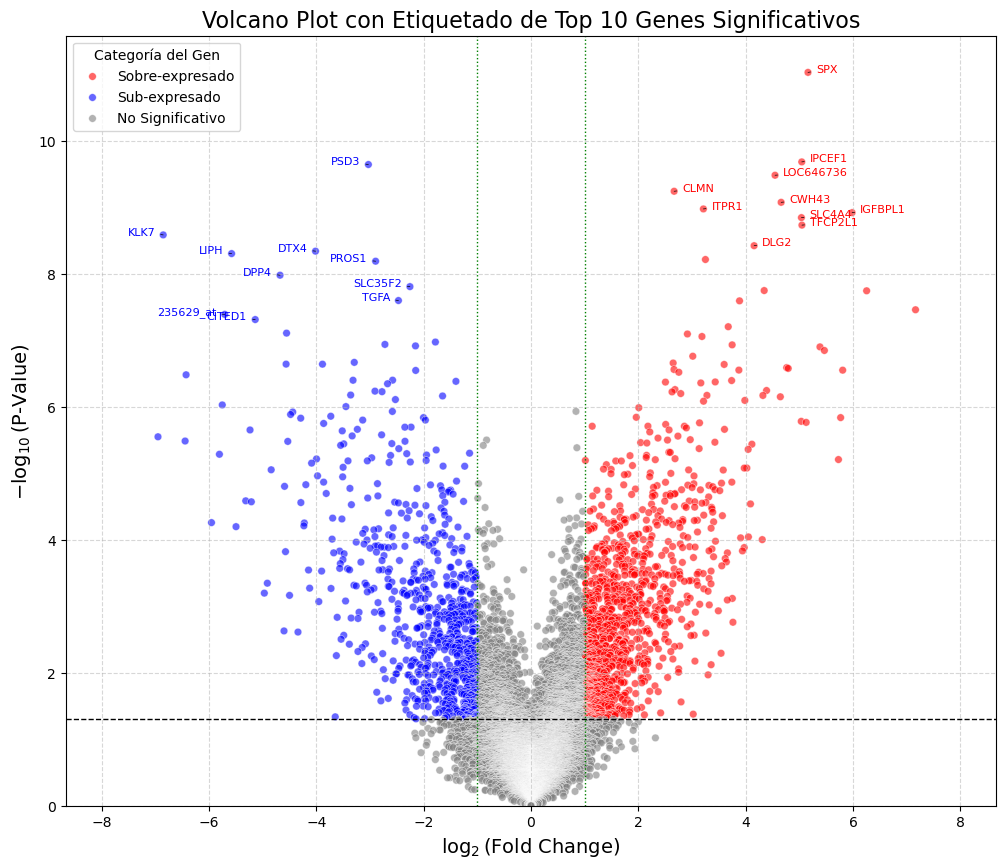

In [6]:

# --- Configuración y Carga de Datos ---
P_VALUE_CUTOFF = 0.05
LOGFC_CUTOFF = 1.0
NEG_LOG10_P_CUTOFF = -np.log10(P_VALUE_CUTOFF)
N_TOP_GENES = 10 # Se etiquetarán los 10 genes más significativos en cada dirección

file_name = 'DE_table.csv'
df = pd.read_csv(file_name, index_col=0)
df['neg_log10_PValue'] = -np.log10(df['P.Value'].clip(lower=1e-300))

# 1. Clasificación y Coloreado 
df['gene_type'] = 'No Significativo'
df.loc[(df['logFC'] > LOGFC_CUTOFF) & (df['P.Value'] < P_VALUE_CUTOFF), 'gene_type'] = 'Sobre-expresado'
df.loc[(df['logFC'] < -LOGFC_CUTOFF) & (df['P.Value'] < P_VALUE_CUTOFF), 'gene_type'] = 'Sub-expresado'

color_map = {'No Significativo': 'gray', 'Sobre-expresado': 'red', 'Sub-expresado': 'blue'}

# --- Generación del Gráfico y Etiquetado ---
plt.figure(figsize=(12, 10))
ax = plt.gca() # Obtener los ejes

sns.scatterplot(
    data=df, x='logFC', y='neg_log10_PValue',
    hue='gene_type', palette=color_map, s=30, alpha=0.6, ax=ax
)

# 2. Selección de los Top N Genes para Etiquetar
df_up = df[df['gene_type'] == 'Sobre-expresado'].sort_values(by='neg_log10_PValue', ascending=False).head(N_TOP_GENES)
df_down = df[df['gene_type'] == 'Sub-expresado'].sort_values(by='neg_log10_PValue', ascending=False).head(N_TOP_GENES)
df_to_label = pd.concat([df_up, df_down])

# 3. Etiquetar cada gen seleccionado
for index, row in df_to_label.iterrows():
    # Usar el SYMBOL del gen o su índice si el símbolo es nulo
    gene_symbol = row['SYMBOL'] if pd.notna(row['SYMBOL']) and row['SYMBOL'] != '' else index
    
    # Determinar el desplazamiento del texto para no tapar el punto
    x_offset = 0.15 if row['logFC'] > 0 else -0.15
    
    # Anotar el punto
    ax.annotate(
        gene_symbol,
        (row['logFC'], row['neg_log10_PValue']),
        xytext=(row['logFC'] + x_offset, row['neg_log10_PValue']),
        fontsize=8,
        color=color_map[row['gene_type']],
        ha='left' if row['logFC'] > 0 else 'right', # Alineación del texto
        arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=0.0", color='black', linewidth=0.5)
    )

# 4. Líneas de corte y etiquetas finales
plt.axhline(y=NEG_LOG10_P_CUTOFF, color='black', linestyle='--', linewidth=1)
plt.axvline(x=LOGFC_CUTOFF, color='green', linestyle=':', linewidth=1)
plt.axvline(x=-LOGFC_CUTOFF, color='green', linestyle=':', linewidth=1)

plt.title(f'Volcano Plot con Etiquetado de Top {N_TOP_GENES} Genes Significativos', fontsize=16)
plt.xlabel(r'$\log_{2}(\text{Fold Change})$', fontsize=14)
plt.ylabel(r'$-\log_{10}(\text{P-Value})$', fontsize=14)
plt.legend(title='Categoría del Gen', loc='upper left')

# Ajustar límites
max_abs_logfc = df['logFC'].abs().max()
plt.xlim(-(max_abs_logfc + 1.5), (max_abs_logfc + 1.5))
plt.ylim(bottom=0)
plt.grid(True, linestyle='--' , alpha=0.5)

plt.savefig('volcano_plot_etiquetado.png', dpi=300, bbox_inches='tight')

In [7]:
ruta_archivo_dos = 'c:/Backup_compu/INIDEP/CURSOS/Bioinformatica_avanzada/TP8/full_matrix.csv'

df_matrix = pd.read_csv(ruta_archivo_dos)
    

In [8]:
print("\nPrimeras 5 filas (Head):")
print(df_matrix.head())


Primeras 5 filas (Head):
              WT_001     WT_002     WT_003     WT_004     WT_005     WT_006  \
1007_s_at   8.939424   8.888303   8.256735   8.765330   8.599826   8.987054   
1053_at     2.709434   2.449028   2.452849   2.451298   2.456036   2.458988   
117_at      2.380946   2.380946   2.380946   2.380946   2.380946   2.380946   
121_at     10.337260  11.248247  10.195061  10.383696  10.798562  11.346987   
1255_g_at   2.315065   2.315065   2.315065   2.315065   2.315065   2.315065   

             WT_007   PTC_001   PTC_002   PTC_003   PTC_004   PTC_005  \
1007_s_at  8.924199  9.177810  9.221119  9.286796  8.985329  9.011876   
1053_at    2.451298  2.449028  2.451787  2.452849  2.452849  2.503228   
117_at     2.380946  2.419864  2.380946  2.380946  2.380946  2.376914   
121_at     9.619388  9.299460  9.899838  9.925744  8.964586  9.749057   
1255_g_at  2.315065  2.315065  2.315065  2.315065  2.315065  2.315065   

             PTC_006   PTC_007  
1007_s_at   9.378741  8.557

In [9]:
print("\nInformación del DataFrame:")
df_matrix.info()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 54675 entries, 1007_s_at to AFFX-TrpnX-M_at
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WT_001   54675 non-null  float64
 1   WT_002   54675 non-null  float64
 2   WT_003   54675 non-null  float64
 3   WT_004   54675 non-null  float64
 4   WT_005   54675 non-null  float64
 5   WT_006   54675 non-null  float64
 6   WT_007   54675 non-null  float64
 7   PTC_001  54675 non-null  float64
 8   PTC_002  54675 non-null  float64
 9   PTC_003  54675 non-null  float64
 10  PTC_004  54675 non-null  float64
 11  PTC_005  54675 non-null  float64
 12  PTC_006  54675 non-null  float64
 13  PTC_007  54675 non-null  float64
dtypes: float64(14)
memory usage: 6.3+ MB


## PCA

C:\Users\Daniela\AppData\Local\Temp\ipykernel_27060\362399160.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(sample, (df_pca['PC1'][i] + 0.1, df_pca['PC2'][i]), fontsize=9)


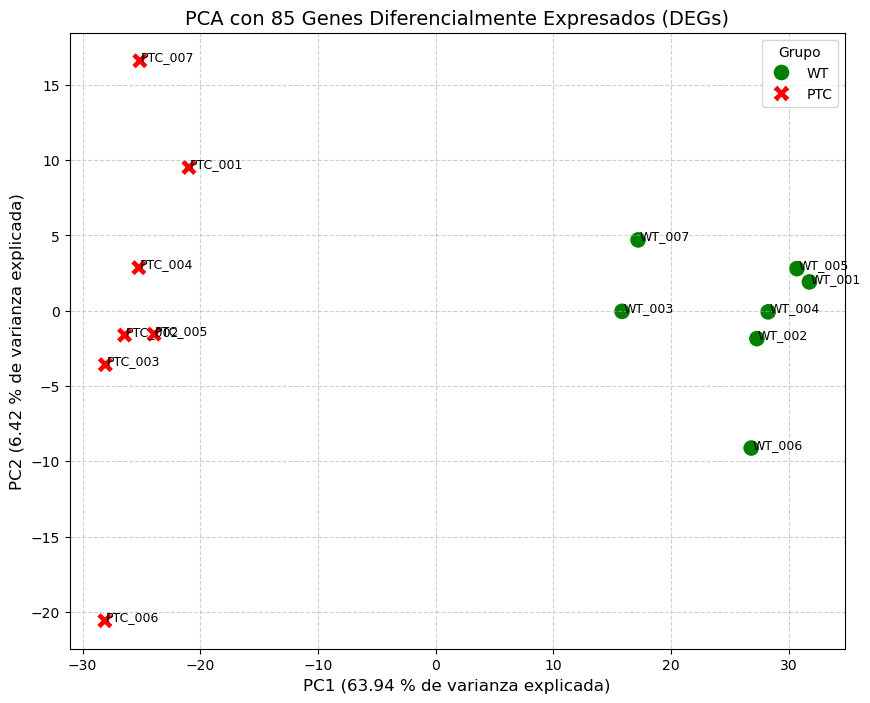

In [ ]:

# --- PASO 1: Obtener la lista de DEGs (85 genes) ---
P_VALUE_CUTOFF = 0.05
LOGFC_CUTOFF = 1.5

df_de = pd.read_csv('DE_table.csv', index_col=0)
filtro_degs = (df_de['P.Value'] < P_VALUE_CUTOFF) & (df_de['logFC'].abs() > LOGFC_CUTOFF)
deg_ids = df_de[filtro_degs].index.tolist()

# --- PASO 2: Cargar y Subsetear la Matriz de Expresión ---
df_expression = pd.read_csv('full_matrix.csv', index_col=0)

# Filtrar la matriz para incluir sólo los DEGs
df_expression_subset = df_expression.loc[deg_ids]

# --- PASO 3: Preparación de Datos para PCA ---
# Transponer: Muestras (filas) x Genes (columnas)
X = df_expression_subset.T

# Extracción de los grupos (WT o PTC) de los nombres de las muestras
groups = X.index.str.split('_').str[0]

# Estandarización de los datos 
X_scaled = StandardScaler().fit_transform(X)

# --- PASO 4: Aplicar PCA ---
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Crear DataFrame para la visualización
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Group'] = groups
df_pca.index = X.index

# --- PASO 5: Visualización del PCA Plot ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Group',
    style='Group',
    s=150,
    palette={'WT': 'green', 'PTC': 'red'}
)

# Añadir etiquetas de las muestras
for i, sample in enumerate(df_pca.index):
    plt.annotate(sample, (df_pca['PC1'][i] + 0.1, df_pca['PC2'][i]), fontsize=9)

# Etiquetas de los ejes (incluyendo la varianza explicada)
variance_ratio = pca.explained_variance_ratio_
pc1_variance = round(variance_ratio[0] * 100, 2)
pc2_variance = round(variance_ratio[1] * 100, 2)

plt.title('PCA con 85 Genes Diferencialmente Expresados (DEGs)', fontsize=14)
plt.xlabel(f'PC1 ({pc1_variance} % de varianza explicada)', fontsize=12)
plt.ylabel(f'PC2 ({pc2_variance} % de varianza explicada)', fontsize=12)
plt.legend(title='Grupo', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('pca_degs_plot.png', dpi=300, bbox_inches='tight')

Se construyó un heatmap utilizando todos los genes diferencialmente expresados (adj. P < 0.05), ordenados 
jerárquicamente mediante complete linkage, con estandarización de los valores de expresión mediante Z-score (por gen).

## Heatmap

c:\Users\Daniela\anaconda3\envs\bioinformatica\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\Daniela\anaconda3\envs\bioinformatica\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


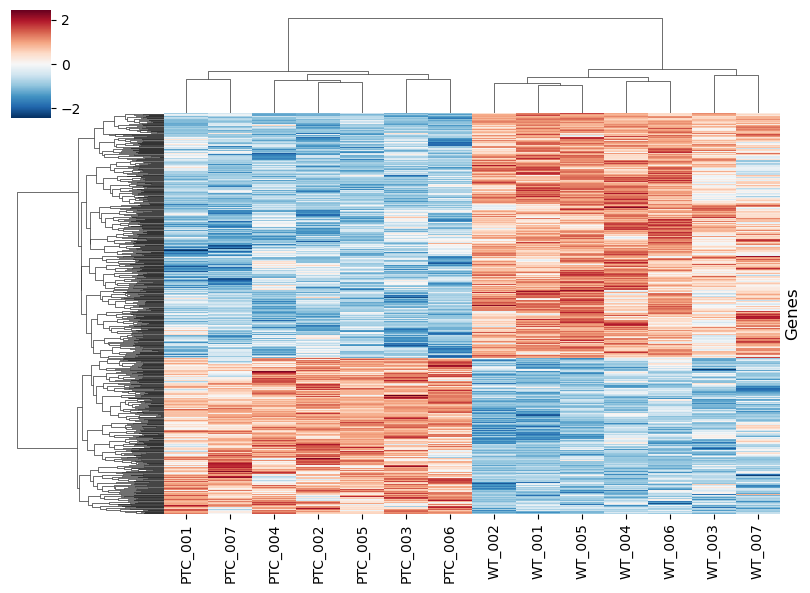

In [12]:


# 1. Cargar datos
de = pd.read_csv("DE_table.csv")
expr = pd.read_csv("full_matrix.csv", index_col=0)

# 2. Filtrar DEGs y tomar top 85
de_sig = de[de["adj.P.Val"] < 0.05]
top_genes = de_sig["Unnamed: 0"]

# 3. Subsetear matriz de expresión
matriz_DEGs = expr.loc[expr.index.intersection(top_genes)]

# 4. Ordenar columnas: WT primero, luego PTC
wt_cols  = [c for c in matriz_DEGs.columns if c.startswith("WT")]
ptc_cols = [c for c in matriz_DEGs.columns if c.startswith("PTC")]
matriz_DEGs = matriz_DEGs[wt_cols + ptc_cols]

# 5. Heatmap como pide el TP
g = sns.clustermap(
    matriz_DEGs,
    method='complete',
    cmap='RdBu_r',
    figsize=(8, 6),
    z_score=0,
    yticklabels=False   
)
# 6. Cambiar etiqueta del eje Y a "Genes"
g.ax_heatmap.set_ylabel("Genes", fontsize=12)

plt.show()


### Objetivo 2. Pathway Enrichment Analysis (PEA) y Gene-Set Enrichment Analysis (GSEA)
En esta sección se realizó un análisis funcional de los datos transcriptómicos. 
PEA y GSEA son dos métodos similares que buscan analizar si los DEGs
pertenecen de manera significativa a ciertas vías metabólicas y/o de señalización y/o de
funciones celualres/moleculares específicas. Para esto se utilizan bases de datos que
contienen listas de genes que se describieron como asociados a alguna vía en particular,
como Gene Ontology (GO), KEGG, Reactome, MSigDB, etc…

### Pathway Enrichment Analysis (PEA)

In [ ]:
gp.get_library_name()

libs = gp.get_library_name()

[h for h in libs if "Human" in h]

['HDSigDB_Human_2021',
 'HumanCyc_2015',
 'HumanCyc_2016',
 'Human_Gene_Atlas',
 'Human_Phenotype_Ontology',
 'JASPAR_PWM_Human_2025',
 'KEGG_2019_Human',
 'KEGG_2021_Human',
 'NURSA_Human_Endogenous_Complexome',
 'Tissue_Protein_Expression_from_Human_Proteome_Map',
 'WikiPathway_2021_Human',
 'WikiPathway_2023_Human',
 'WikiPathways_2019_Human',
 'WikiPathways_2024_Human']

In [ ]:
# Cargar tabla de DEGs
de = pd.read_csv("DE_table.csv")

# Limpiar la columna SYMBOL
genelist = (
    de["SYMBOL"]
    .dropna()            # eliminar NA
    .astype(str)          # asegurar string
    .str.upper()           # convertir a mayúsculas
    .unique()              # por si hay repetidos
    .tolist()              # pasar a lista
)

print("Número de genes:", len(genelist))
genelist[:10]

Número de genes: 21405


['SPX',
 'IPCEF1',
 'PSD3',
 'LOC646736',
 'CLMN',
 'CWH43',
 'ITPR1',
 'IGFBPL1',
 'SLC4A4',
 'TFCP2L1']

In [ ]:
gene_sets = [
    "KEGG_2021_Human",
    "WikiPathway_2023_Human",
    "HDSigDB_Human_2021"
]

In [ ]:
# Parche para hacer compatible gseapy con pandas >= 2.0
pd.DataFrame.append = lambda self, other, ignore_index=False: pd.concat(
    [self, other], ignore_index=ignore_index
)

In [ ]:
print(genelist[:20])   # primeros 20
print(len(genelist))

['SPX', 'IPCEF1', 'PSD3', 'LOC646736', 'CLMN', 'CWH43', 'ITPR1', 'IGFBPL1', 'SLC4A4', 'TFCP2L1', 'KLK7', 'DLG2', 'DTX4', 'LIPH', 'GHR', 'PROS1', 'DPP4', 'SLC35F2', 'TMPRSS3', 'PKHD1L1']
21405


In [ ]:
[x for x in genelist if " " in x or "_" in x or "-" in x][:20]

['SLC26A4-AS1',
 'LRRC52-AS1',
 'RAB30-DT',
 'NR2F1-AS1',
 'NUDT16-DT',
 'DCTN1-AS1',
 'PRDM16-DT',
 'FAM111A-DT',
 'IQCH-AS1',
 'TDRKH-AS1',
 'NRSN2-AS1',
 'GALNT7-DT',
 'EIF2AK3-DT',
 'RBM26-AS1',
 'HLA-B',
 'RUNDC3A-AS1',
 'EP300-AS1',
 'LRIG2-DT',
 'OR2A1-AS1',
 'AP1G2-AS1']

In [ ]:
genelist = [g.strip().upper() for g in genelist if pd.notna(g)]

In [ ]:
small_list = genelist[:1000]

enr = gp.enrichr(
    gene_list = small_list,
    gene_sets = ["KEGG_2021_Human", "WikiPathway_2023_Human","HDSigDB_Human_2021"],
    outdir = "PEA_results",
    cutoff = 0.05,
    no_plot = True
)

enr.results.head()

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_set
0,MAPK signaling pathway,34/294,0.000005,0.001444,0,0,2.536869,31.019726,FLT1;SRF;TGFA;NLK;EFNA5;RPS6KA6;RPS6KA5;ERBB3;...,KEGG_2021_Human
1,ECM-receptor interaction,15/88,0.000028,0.002602,0,0,3.948335,41.347418,SDC4;LAMB3;ITGA3;ITGA2;ITGA1;FN1;COL1A1;RELN;I...,KEGG_2021_Human
2,AGE-RAGE signaling pathway in diabetic complic...,16/100,0.000035,0.002602,0,0,3.661634,37.581630,EGR1;JUN;STAT1;FN1;FOXO1;TGFBR1;MAPK13;VEGFA;C...,KEGG_2021_Human
3,Proteoglycans in cancer,25/205,0.000035,0.002602,0,0,2.680912,27.484725,SDC4;SDC2;ITPR1;CCND1;ERBB3;ERBB4;KDR;TIMP3;PR...,KEGG_2021_Human
4,Tight junction,21/169,0.000111,0.006541,0,0,2.732325,24.883878,JUN;MSN;CLDN1;MYL12A;RUNX1;MAPK10;TIAM1;CLDN10...,KEGG_2021_Human


In [ ]:
enr_genes = enr.res2d.shape
print(enr_genes)

(2404, 10)


Se obtuvieron 2404 pathways / términos enriquecidos de 3 bases de datos combinadas:

- KEGG
- WikiPathway
- HDSigDB

Cada fila representa un pathway diferente asociado a los genes PTC vs WT.

In [ ]:
#columnas del df
columns_df = enr.res2d.columns
print(columns_df)

Index(['Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value',
       'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes',
       'Gene_set'],
      dtype='object')


Cada fila corresponde a una vía metabólica o de señalización listada en alguna de
las bases de datos que se indicaron. La columna “Gene_set” indica la base de datos de
donde proviene la lista de genes correspondiente a esa vía, “Term” es el nombre de la lista
de genes, “Overlap” es la cantidad de genes de su lista que coincidieron con la lista de la
vía. Luego viene una serie de columnas con valores estadísticos, de las cuales la única
particularmente relevante es “Adjusted P-value” (esta indica si las coincidencias de genes
en la vía son atribuibles al azar o si hay un enriquecimiento verdadero en genes de esa vía)
y por último “Genes” que es la lista de genes nuestros que coincidieron con los de la vía.

In [ ]:
#Aplicación de filtros
#Se filtran genes significativos (FDR < 0.05)
sig = enr.results[enr.results["Adjusted P-value"] < 0.05]
shape_tuple = sig.shape
porcentaje = shape_tuple[0]*100/enr_genes[0]
print("Número de genes significativos:", shape_tuple[0])
print(f"El número de genes significativos representa el {porcentaje:.2f}%")

Número de genes significativos: 1135
El número de genes significativos representa el 47.21%


In [ ]:
top30 = sig.sort_values(by="Adjusted P-value").head(5)
top30[["Term", "Adjusted P-value", "Gene_set"]]

,Term,Adjusted P-value,Gene_set
936,Genes Changed In Astrocytes Of HD Patients Vs ...,4.565395e-33,HDSigDB_Human_2021
937,Genes Up-Regulated In Friedreich Ataxia iPSCs ...,9.334681e-33,HDSigDB_Human_2021
938,Genes Changed In Brain And Spinal Cord Derived...,5.359183e-32,HDSigDB_Human_2021
939,Expression In NSCs Lines HD180i.5 And HD60i.4 ...,1.275436e-31,HDSigDB_Human_2021
940,Genes Changed In Foxp2/Olfm3-expressing Neuron...,2.139065e-31,HDSigDB_Human_2021


## Barplot

Vías metabólicas: 30
Gene_set
WikiPathway_2023_Human    18
KEGG_2021_Human            9
HDSigDB_Human_2021         3
Name: count, dtype: int64


C:\Users\Daniela\AppData\Local\Temp\ipykernel_26088\3453894329.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


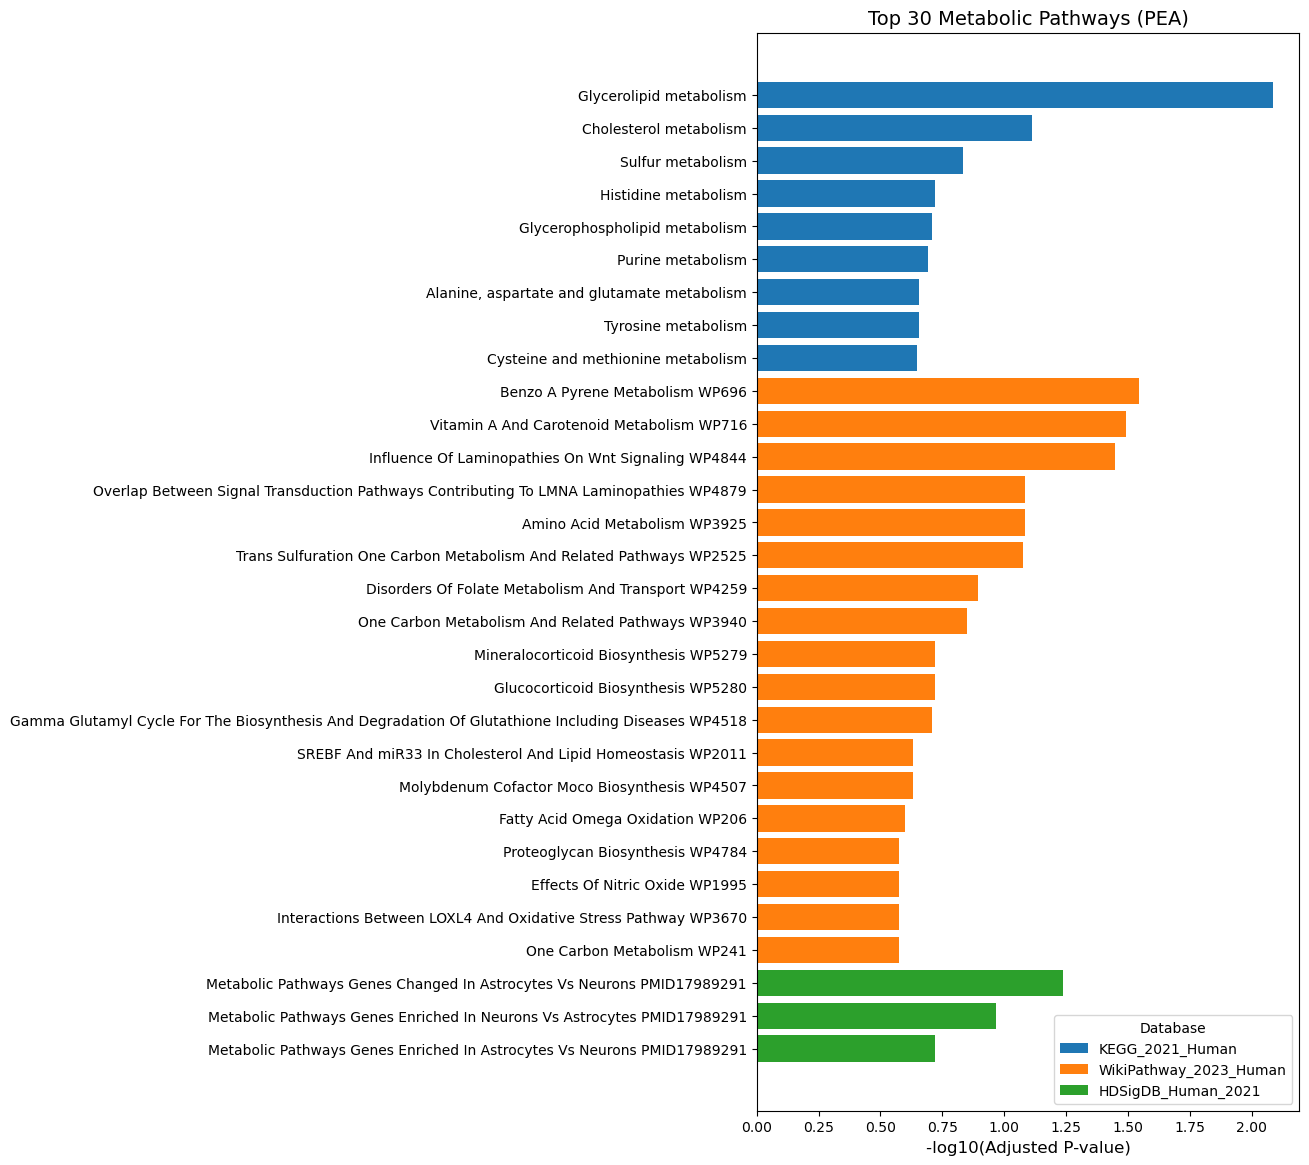

In [ ]:
# 1. Filtrar rutas metabólicas
metabolic = enr.results[
    enr.results["Term"].str.contains(
        "metabo|biosynth|glyco|lipid|amino|carbo|fatty|tca|oxid",
        case=False,
        na=False
    )
]

# 2. Limpiar, ordenar y quedarnos con las 30 mejores
metabolic = (
    metabolic
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["Adjusted P-value"])
    .query("`Adjusted P-value` > 0")
    .sort_values("Adjusted P-value")
    .drop_duplicates(subset="Term")
    .head(30)
)

print("Vías metabólicas:", metabolic.shape[0])
print(metabolic["Gene_set"].value_counts())

# 3. Crear colores por base de datos
color_dict = {
    "KEGG_2021_Human": "#1f77b4",
    "WikiPathway_2023_Human": "#ff7f0e",
    "HDSigDB_Human_2021": "#2ca02c"
}

# 4. Figura
plt.figure(figsize=(7, 14))

# 5. Plot por cada base de datos 
for gs in metabolic["Gene_set"].unique():
    subset = metabolic[metabolic["Gene_set"] == gs]

    plt.barh(
        subset["Term"],
        -np.log10(subset["Adjusted P-value"]),
        label=gs,
        color=color_dict.get(gs, "gray")
    )

# 6. Estética
plt.xlabel("-log10(Adjusted P-value)", fontsize=12)
plt.title("Top 30 Metabolic Pathways (PEA)", fontsize=14)
plt.legend(title="Database")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Dotplot

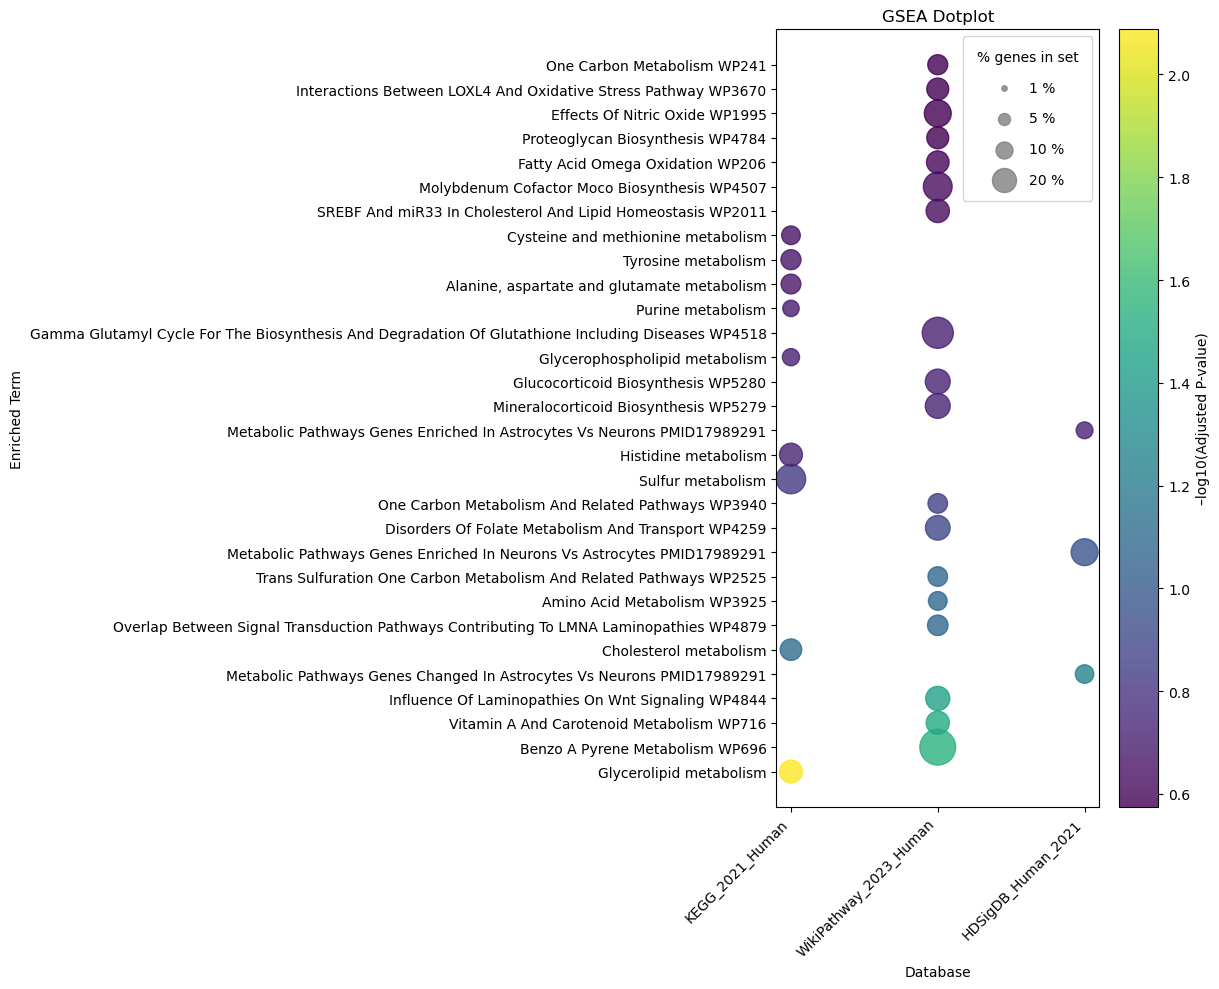

In [ ]:

# 1. Tomar resultados de gseapy
df = enr.res2d.copy()

# 2. Crear columnas necesarias
# –log10(Adjusted P-value)
df["minus_log10_adjP"] = -np.log10(df["Adjusted P-value"])

# % de genes en el set (a partir de Overlap: ej. "5/130")
df["percent_genes"] = df["Overlap"].apply(
    lambda x: (int(x.split("/")[0]) / int(x.split("/")[1])) * 100
)

# Quedarse con los 30 más significativos
top = df.sort_values("Adjusted P-value").head(30)

# 3. DOTPLOT con colorbar continuo

plt.figure(figsize=(12, 10))

sc = plt.scatter(
    x=top["Gene_set"],           # bases de datos
    y=top["Term"],               # términos
    s=top["percent_genes"] * 15, # tamaño (% genes)
    c=top["minus_log10_adjP"],   # color (-log10 adj pval)
    cmap="viridis",
    alpha=0.8
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Database")
plt.ylabel("Enriched Term")
plt.title("GSEA Dotplot")

# 4. COLORBAR CONTINUA
cbar = plt.colorbar(sc)
cbar.set_label("–log10(Adjusted P-value)")

# 5. LEYENDA DE TAMAÑO (% genes)
# valores de referencia para el tamaño
size_values = [1, 5, 10, 20]  

# crear puntos para la leyenda
for size in size_values:
    plt.scatter([], [], 
                s=size*15, 
                c='gray', 
                alpha=0.8,
                label=f"{size} %")

plt.legend(
    title="% genes in set",
    labelspacing=1.2,
    borderpad=1,
    frameon=True,
    loc="upper right"
)

plt.tight_layout()
plt.show()

A pesar de la utilidad de PEA, esta técnica tiene dos limitaciones: no es capaz de
distinguir qué genes están sobre o sub expresados en cada condición (a menos que uno lo
arregle manualmente) y por ende no se puede saber qué vías están prendidas o apagadas
en cada caso; y además está condicionado por los criterios de corte elegidos para los
DEGs, es decir, que los resultados de PEA van a depender de cuántos y cómo hayamos
seleccionado los DEGs.

## Gene-Set Enrichment analysis (GSEA)

GSEA a diferencia de PEA no usa los DEGs, usa todos los genes y los rankea con un sistema de puntaje que combina el logFC y
el p-value. Este rankeo utiliza el signo del logFC, con lo que el sentido de la expresión (sub o sobre) está considerado. 
Este rankeo nos independiza del problema del filtrado de DEGs porque tiene en cuenta la magnitud del logFC y del p-value 
para todos los genes, y además el signo del logFC le da direccionalidad.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54675 entries, 229778_at to AFFX-TrpnX-M_at
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   logFC             54675 non-null  float64
 1   AveExpr           54675 non-null  float64
 2   t                 54675 non-null  float64
 3   P.Value           54675 non-null  float64
 4   adj.P.Val         54675 non-null  float64
 5   B                 54675 non-null  float64
 6   SYMBOL            44707 non-null  object 
 7   REFSEQ            44451 non-null  object 
 8   ENTREZID          44707 non-null  float64
 9   GENENAME          44707 non-null  object 
 10  ENSEMBL           42997 non-null  object 
 11  neg_log10_PValue  54675 non-null  float64
 12  gene_type         54675 non-null  object 
dtypes: float64(8), object(5)
memory usage: 7.9+ MB


In [19]:
# 1. Copiamos la tabla original
df_ = df.copy()

# 2. Ordenar en sentido descendente
df_["rank"] = -np.log10(df_["P.Value"]) * df_["logFC"]

# 3. Crear dataframe solo con SYMBOL y rank
df_GSEA = df_.sort_values("rank", ascending=False)

# 4. Convertir todos los genes en mayúsculas
df_GSEA["SYMBOL"] = df_GSEA["SYMBOL"].str.upper()

# 5. Elimina filas con valores faltantes
df_GSEA = df_GSEA.dropna()

# 6. Convertir al formato que espera GSEA (Series ordenada)
#GSEAPY necesita un ranking en forma de Serie de Pandas:
rnk = df_GSEA.set_index("SYMBOL")["rank"]
rnk.head()


SYMBOL
SPX        56.906319
PKHD1L1    53.427768
IGFBPL1    53.348926
IPCEF1     48.835695
PKHD1L1    48.417702
Name: rank, dtype: float64

In [20]:
# 7. Ejecutar GSEA en gseapy
gene_sets = ["KEGG_2021_Human",
             "WikiPathway_2023_Human",
             "HDSigDB_Human_2021"]

gsea_results = []

for gs in gene_sets:
    
    print(f"Running GSEA for {gs} ...")

    gsea = gp.prerank(
        rnk = rnk,
        gene_sets = gs,
        outdir = f"GSEA_results/{gs}",
        min_size = 15,
        max_size = 500,
        permutation_num = 100,
        seed = 42,
        no_plot = True,
        verbose = False
    )
    
    res = gsea.res2d.copy()
    res["Gene_set"] = gs
    gsea_results.append(res)

# Unimos todo
df_GSEA = pd.concat(gsea_results)
df_GSEA.head()

2025-11-25 22:18:30,376 Input gene rankings contains duplicated IDs, Only use the duplicated ID with highest value!


Running GSEA for KEGG_2021_Human ...


2025-11-25 22:19:42,826 Input gene rankings contains duplicated IDs, Only use the duplicated ID with highest value!


Running GSEA for WikiPathway_2023_Human ...


2025-11-25 22:21:33,352 Input gene rankings contains duplicated IDs, Only use the duplicated ID with highest value!


Running GSEA for HDSigDB_Human_2021 ...


,es,nes,pval,fdr,geneset_size,matched_size,genes,Gene_set
Term,,,,,,,,
Asthma,-0.879596,-1.656020,0.000000,0.054271,31,28,"TNF,HLA-DOB,HLA-DPB1,CD40,PRG2,RNASE3,IL10,IL5...",KEGG_2021_Human
One carbon pool by folate,-0.855543,-1.563586,0.050000,0.085930,20,19,"AMT,MTR,SHMT1,DHFR2,MTHFD1,MTHFD2L,MTFMT,FTCD,...",KEGG_2021_Human
Serotonergic synapse,0.876348,1.364895,0.000000,0.116187,113,107,"ITPR1,GNAS,GNAI1,GABRB3,DUSP1,PRKACB,PRKCA,GNG...",KEGG_2021_Human
"Growth hormone synthesis, secretion and action",0.821582,1.333421,0.010526,0.139200,119,119,"ITPR1,GHR,IRS4,GNAS,GNAI1,IRS1,FOS,SOCS2,PRKAC...",KEGG_2021_Human
Cortisol synthesis and secretion,0.852667,1.327723,0.011494,0.142363,65,65,"ITPR1,GNAS,AGTR1,CYP17A1,PRKACB,CACNA1D,PDE8B,...",KEGG_2021_Human


De las columnas que presenta df_GSEA cabe destacar “Term” que corresponde a la vía o lista de genes proveniente de base de datos, 
“ES” y “NES” que son “Enrichment Score” y “Normalized Enrichment Score”, que son puntajes que miden el
enriquecimiento de ese término en genes sobreexpresión o subexpresados según el caso.
“FDR q-val” es el p-value ajustado para esa fila y “Lead_genes” son los genes que están
determinando que ese término está sobreexpresado o subexpresado.

In [29]:
list(gsea.results.keys())[:20]

['ATN1-ATXN2 Shared Co-Expressed Genes In HD-associated Brain Region PMID29249939',
 'ATN1-HTT Shared Co-Expressed Genes In HD-associated Brain Region PMID29249939',
 'Activity-dependent Synaptic AMPA Receptor Removal CHDI115',
 'Aged Astrocyte-Enriched Genes In Mouse Cortex PMID23954174',
 'Aged Microglia-Enriched Genes In Mouse Cortex PMID23954174',
 'Alternative Priming Pathway Genes Changed In Old Vs Young Microglia PMID24162652',
 'Alternative Priming Pathway Genes Up-Regulated In Old Vs Young Microglia PMID24162652',
 'Alzheimer Disease Down-Regulated Genes In CA1 Area Of Hippocampus Colangelo PMID12391607',
 'Alzheimer Disease Related Gene Module From Human Brain PMID20616000',
 'Alzheimer Disease Up-Regulated Genes In CA1 Area Of Hippocampus Colangelo PMID12391607',
 'Amygdala And Hippocampal Pyramidal Neuron Gene Module PMID19638972',
 'Anterior Cingulate Cortex And Caudate Nucleus Coexpressed Gene Module PMID17101986',
 'Astrocyte Gene Markers PMID17151600',
 'Astrocyte Gene 